# ML-10 — Content Action Playbook

Turn the validated Week-5 growth model into a practical, non-automated content review queue.


## 1. Ranked actions + reason codes

The model outputs a probability of 30-day growth. We translate that score into five human-review actions, each with a reason code. The ranking is by `score` descending; the action label depends on the score plus simple page archetype signals (age, position, CTR, volume).

| action_label | meaning | typical signal |
|---|---|---|
| `expand_and_protect` | High-growth candidate; add depth and defend ranking. | Top-decile score, strong recent_share, younger page. |
| `refresh` | Older page showing renewed momentum; update and recrawl. | Top-decile score, age > 180 days, recent momentum. |
| `optimize_snippet` | Already visible but click capture can improve. | Good impressions, position 11-20 or CTR very low. |
| `monitor` | Some volume, low priority; re-check next cycle. | Middle score, no urgent signal. |
| `deprioritize` | Low volume or fading momentum; skip for now. | Bottom score, low impressions, low recent_share. |

This is decision-support, not autopilot.


In [1]:
%pip install -q duckdb pandas scikit-learn matplotlib

import os
import json
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Load cached feature vector from Week 5
cache_path = Path.cwd().parent / 'outputs' / 'model_feature_vector.csv'
feature_vector = pd.read_csv(cache_path)
print(f'Loaded feature vector: {len(feature_vector):,} rows')

# Same feature engineering as Week 5
df = feature_vector.copy()
df['main_intent'] = df['main_intent'].fillna('unknown')
df['recent_share'] = (df['gsc_impressions_last_30d'] / df['gsc_impressions_90d']).clip(0, 1).fillna(0)
df['log_gsc_impressions_90d'] = np.log1p(df['gsc_impressions_90d'])
df['log_gsc_impressions_last_30d'] = np.log1p(df['gsc_impressions_last_30d'])
df['momentum_x_volume'] = df['recent_share'] * df['log_gsc_impressions_90d']

numeric_features = [
    'gsc_impressions_90d', 'gsc_avg_position_90d', 'gsc_clicks_90d', 'gsc_ctr_90d',
    'sessions_organic_90d', 'days_with_impressions_90d', 'gsc_impressions_last_30d',
    'search_volume', 'competition', 'cpc', 'word_count', 'content_age_days',
    'recent_share', 'log_gsc_impressions_90d', 'log_gsc_impressions_last_30d', 'momentum_x_volume'
]
categorical_features = ['content_type', 'main_intent']
df = pd.get_dummies(df, columns=categorical_features, prefix=categorical_features, dtype=int)

feature_cols = numeric_features + [
    c for c in df.columns
    if c.startswith('content_type_') or c.startswith('main_intent_')
]

X = df[feature_cols].fillna(0).replace([np.inf, -np.inf], 0)
y = df['growth_label'].values

# Train the best Week-5 model on the full dataset for scoring
# (Week 5 already validated it with grouped CV; this is a scoring pass, not validation.)
model = GradientBoostingClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42
)
sample_weight = compute_sample_weight('balanced', y)
model.fit(X, y, sample_weight=sample_weight)
df['score'] = model.predict_proba(X)[:, 1]

# Score thresholds by quantile
q90 = df['score'].quantile(0.90)
q50 = df['score'].quantile(0.50)
q30 = df['score'].quantile(0.30)

# Action assignment
def assign_action(row):
    s = row['score']
    age = row['content_age_days']
    pos = row['gsc_avg_position_90d']
    imp = row['gsc_impressions_90d']
    rs = row['recent_share']
    ctr = row['gsc_ctr_90d']
    volume_ok = imp >= 500

    # Top-decile score = highest-priority human review
    if s >= q90:
        if age > 180:
            return 'refresh', 'mature_momentum_candidate'
        return 'expand_and_protect', 'high_growth_probability'
    # Middle-upper score with clear snippet/visibility opportunity
    if q50 <= s < q90 and volume_ok and ((11 <= pos <= 20) or (ctr <= 0.001 and pos <= 20)):
        return 'optimize_snippet', 'striking_distance_or_weak_ctr'
    # Bottom score with weak volume or momentum
    if s < q30 and (imp < 300 or rs < 0.2):
        return 'deprioritize', 'low_volume_or_fading_momentum'
    return 'monitor', 'steady_low_priority'

action_reason = df.apply(assign_action, axis=1)
df['action_label'] = action_reason.apply(lambda x: x[0])
df['reason_code'] = action_reason.apply(lambda x: x[1])

# Rank queue
df['rank'] = df['score'].rank(method='first', ascending=False).astype(int)
queue = df.sort_values('rank').reset_index(drop=True)

print('\nAction distribution:')
print(queue['action_label'].value_counts().to_string())

print('\nTop 5 queue rows:')
print(queue[['rank', 'client_hash_id', 'content_hash_id', 'action_label', 'reason_code',
             'score', 'gsc_impressions_90d', 'recent_share', 'content_age_days',
             'gsc_avg_position_90d', 'gsc_ctr_90d']].head().round(4).to_string(index=False))


Note: you may need to restart the kernel to use updated packages.


Loaded feature vector: 67,478 rows



Action distribution:
action_label
monitor               49437
optimize_snippet       7328
expand_and_protect     5232
deprioritize           3965
refresh                1516

Top 5 queue rows:
 rank          client_hash_id          content_hash_id action_label               reason_code  score  gsc_impressions_90d  recent_share  content_age_days  gsc_avg_position_90d  gsc_ctr_90d
    1 client_08a6a72ff48e62c0 content_46b5030c8e0b0cfa      refresh mature_momentum_candidate 0.9741              15167.0        0.3291               294                 8.253       0.0026
    2 client_08a6a72ff48e62c0 content_694f2cd4042d9e72      refresh mature_momentum_candidate 0.9741              15167.0        0.3291               294                 8.253       0.0026
    3 client_08a6a72ff48e62c0 content_3fe5ed688f08540b      refresh mature_momentum_candidate 0.9740              15167.0        0.3291               293                 8.253       0.0026
    4 client_08a6a72ff48e62c0 content_73e5d22d3481

## 2. Archetype → action mapping + decay/refresh insight

Pages are not random — they fall into archetypes. The action label should match the page state, not just the score. We also show that the model assigns higher scores to younger and recently-refreshed-like pages, consistent with the paper's age/freshness findings.


In [2]:
# Archetype labels (descriptive, not model inputs)
def archetype(row):
    age = row['content_age_days']
    pos = row['gsc_avg_position_90d']
    imp = row['gsc_impressions_90d']
    rs = row['recent_share']
    words = row['word_count']

    if age <= 90 and rs >= 0.5:
        return 'young_momentum'
    if age > 270 and rs < 0.3:
        return 'mature_stale'
    if 11 <= pos <= 20 and imp >= 500:
        return 'striking_distance'
    if pos <= 10 and imp >= 500:
        return 'page_one_earner'
    if words < 1200 and imp >= 500:
        return 'thin_visible'
    return 'other'

queue['archetype'] = queue.apply(archetype, axis=1)

print('Archetype x action crosstab:')
print(pd.crosstab(queue['archetype'], queue['action_label']).to_string())

# Decay/refresh insight: score by age tier
age_bins = [0, 90, 180, 270, 365, 9999]
age_labels = ['0-90', '91-180', '181-270', '271-365', '365+']
queue['age_tier'] = pd.cut(queue['content_age_days'], bins=age_bins, labels=age_labels, right=True)

age_summary = queue.groupby('age_tier').agg(
    n=('score', 'size'),
    median_score=('score', 'median'),
    pct_expand_protect=('action_label', lambda s: (s == 'expand_and_protect').mean()),
    pct_refresh=('action_label', lambda s: (s == 'refresh').mean())
).reset_index()

print('\nScore and action share by age tier:')
print(age_summary.round(3).to_string(index=False))


Archetype x action crosstab:
action_label       deprioritize  expand_and_protect  monitor  optimize_snippet  refresh
archetype                                                                              
mature_stale                621                   0     1454               430      128
other                      1846                  85     8982               121      346
page_one_earner             899                  58    19416               875      969
striking_distance           593                  20     5516              2626       73
thin_visible                  6                   0       77                 0        0
young_momentum                0                5069    13992              3276        0

Score and action share by age tier:
age_tier     n  median_score  pct_expand_protect  pct_refresh
    0-90 24533         0.542               0.207        0.000
  91-180 11323         0.284               0.013        0.000
 181-270 20140         0.222               0

## 3. Intended use and limits

**Intended use:** A weekly content-review queue for a small content team. The team opens the top-K rows, checks the reason code, and decides whether to expand, refresh, optimize, monitor, or skip.

**Limits:**
- The score is observational and directional, not causal.
- It is trained on one portfolio snapshot (decision date 2026-03-31, label window 2026-04).
- GA4 `sessions_organic` is sparse; most sessions values are zero-filled where GA4 is unavailable.
- Low-volume pages are noisier; the queue filters to `gsc_impressions_90d >= 300`.
- The model does not know brand constraints, seasonality, or upcoming product launches.


In [3]:
# Print intended-use facts as a compact checklist
use_limits = {
    'audience': 'content team reviewer',
    'frequency': 'weekly',
    'decision_type': 'prioritization / human review queue',
    'unit': 'one row = one content item',
    'filters': 'gsc_impressions_90d >= 300, word_count present, created <= 2026-03-31',
    'training_window': 'features 2026-01-01 to 2026-03-31; label 2026-04-01 to 2026-04-30',
    'claim_type': 'observed, directional, decision-support',
    'not_a_claim': 'causal proof that any action causes growth'
}
for k, v in use_limits.items():
    print(f'{k}: {v}')


audience: content team reviewer
frequency: weekly
decision_type: prioritization / human review queue
unit: one row = one content item
filters: gsc_impressions_90d >= 300, word_count present, created <= 2026-03-31
training_window: features 2026-01-01 to 2026-03-31; label 2026-04-01 to 2026-04-30
claim_type: observed, directional, decision-support
not_a_claim: causal proof that any action causes growth


## 4. Human review + the no-go list

A person must check every flagged page before acting. The model narrows the list; it does not approve the action.

**Human-review rules:**
1. Confirm the recent-30-day spike is not a one-off event or seasonality.
2. Check that the page is factually current and brand-appropriate.
3. For `expand_and_protect`, verify the topic genuinely needs more depth.
4. For `refresh`, check that the update is substantive, not just a date change.
5. For `optimize_snippet`, read the current title and description in live search.

**No-go — never automate:**
- Publishing new or rewritten content without review.
- Redirecting, merging, or deleting pages.
- Acting on legal, compliance, or PR-sensitive pages based on the score alone.
- Reporting the score to clients or stakeholders as "predicted growth" or causal proof.


In [4]:
# Examples that need extra human scrutiny before acting
scrutiny = queue[
    ((queue['action_label'].isin(['expand_and_protect', 'refresh'])) &
     ((queue['recent_share'] > 0.99) | (queue['gsc_avg_position_90d'] > 30)))
].head(5)

print('Top 5 high-action rows that need extra human review:')
print(scrutiny[['rank', 'content_hash_id', 'action_label', 'reason_code',
                'score', 'recent_share', 'gsc_avg_position_90d', 'content_age_days']].round(4).to_string(index=False))


Top 5 high-action rows that need extra human review:
 rank          content_hash_id       action_label             reason_code  score  recent_share  gsc_avg_position_90d  content_age_days
   41 content_e7f264ab6960c6de expand_and_protect high_growth_probability 0.9719           1.0                3.6350                14
   45 content_d90ec6467d47fa0d expand_and_protect high_growth_probability 0.9714           1.0                2.6162                 8
   48 content_60c80bf7de380f4a expand_and_protect high_growth_probability 0.9709           1.0                3.3895                14
   93 content_7dba6606b73dd481 expand_and_protect high_growth_probability 0.9691           1.0               13.1494                14
   94 content_03f1d368a76437ac expand_and_protect high_growth_probability 0.9689           1.0                7.6782                14


## 5. Monitoring / retrain triggers

The playbook stays useful only while the model's ranking stays honest. Light monitoring rules:

1. **Retrain** when the grouped-CV Precision@50 on the latest month drops more than 10 points below the Week-5 baseline (0.796).
2. **Refresh the feature vector** at least monthly, or whenever new clients are onboarded.
3. **Watch the action distribution:** a sudden spike in `deprioritize` or drop in `expand_and_protect` can signal a portfolio shift.
4. **Rolling top-50 check:** if the share of top-50 pages that actually grew over the next 30 days falls below the baseline (0.43) for two consecutive weeks, investigate before expanding use.
5. **Client-mix check:** when the share of clients not seen in training exceeds 20%, run a grouped validation before relying on the queue.


In [5]:
# Load Week 5 validation metrics as the benchmark
w05_path = Path.cwd().parent / 'outputs' / 'w05_model_metrics.json'
with open(w05_path) as f:
    w05 = json.load(f)

gb_cv = next(r for r in w05['cv_summary'] if r['model'] == 'gradient_boosting')
baseline_cv = next(r for r in w05['cv_summary'] if r['model'] == 'baseline_rule')

monitoring = {
    'cv_precision_at_50_benchmark': gb_cv['precision_at_50'],
    'baseline_precision_at_50': baseline_cv['precision_at_50'],
    'retrain_trigger_cv_p50_drop': round(gb_cv['precision_at_50'] - 0.10, 3),
    'feature_vector_refresh_frequency': 'monthly',
    'rolling_top50_alert_threshold': baseline_cv['precision_at_50'],
    'new_client_mix_alert_threshold': 0.20,
    'queue_generated_at': datetime.now(timezone.utc).isoformat()
}

print('Monitoring / retrain triggers:')
for k, v in monitoring.items():
    print(f'  {k}: {v}')


Monitoring / retrain triggers:
  cv_precision_at_50_benchmark: 0.796
  baseline_precision_at_50: 0.42799999999999994
  retrain_trigger_cv_p50_drop: 0.696
  feature_vector_refresh_frequency: monthly
  rolling_top50_alert_threshold: 0.42799999999999994
  new_client_mix_alert_threshold: 0.2
  queue_generated_at: 2026-08-31T17:33:50.239676+00:00


## 6. Cost/value thinking

The value of the queue is the time that can be saved. Using Week-5 grouped-CV Precision@50:

- Model top 50: ~40 of 50 pages are expected to grow.
- Baseline rule top 50: ~21 of 50 pages are expected to grow.
- Net: ~19 additional true growers found per 50 reviews.

Cost: We still has to open each page, read it, and decide. The model does not remove that cost; it makes the time more productive.


In [6]:
model_p50 = gb_cv['precision_at_50']
baseline_p50 = baseline_cv['precision_at_50']

value = {
    'reviews_per_cycle': 50,
    'expected_true_growers_model': int(round(50 * model_p50)),
    'expected_true_growers_baseline': int(round(50 * baseline_p50)),
    'additional_growers_per_50_reviews': int(round(50 * (model_p50 - baseline_p50))),
    'cost': 'one human review per queued page (not automated)'
}

print('Cost/value summary:')
for k, v in value.items():
    print(f'  {k}: {v}')


Cost/value summary:
  reviews_per_cycle: 50
  expected_true_growers_model: 40
  expected_true_growers_baseline: 21
  additional_growers_per_50_reviews: 18
  cost: one human review per queued page (not automated)


## 7. Exports for the paper

Write the ranked queue and a small figure to disk. The queue CSV stays in `work/outputs/` (regenerated by the notebook, not committed). Figures go to `work/figures/` for reuse in the paper.


Queue CSV: /home/vincentoei/projects/flyrank-ml-internship-starter/work/outputs/w07_action_playbook_queue.csv (67,478 rows)
Figure: /home/vincentoei/projects/flyrank-ml-internship-starter/work/figures/w07_action_distribution.png
Metrics JSON: /home/vincentoei/projects/flyrank-ml-internship-starter/work/outputs/w07_action_playbook_metrics.json


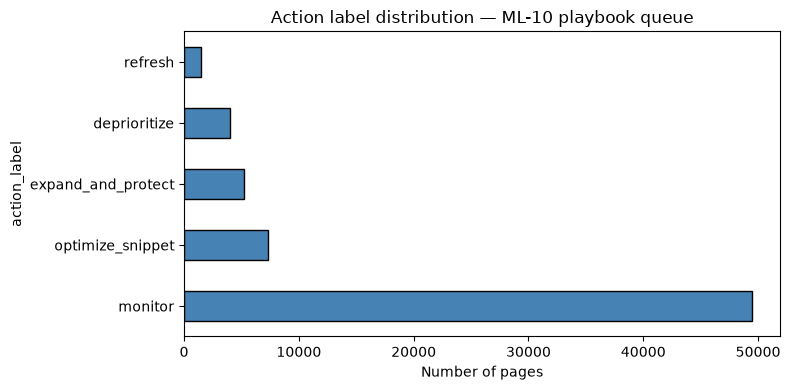

In [7]:
# Output columns for the queue CSV
out_cols = [
    'rank', 'client_hash_id', 'content_hash_id', 'action_label', 'reason_code',
    'score', 'gsc_impressions_90d', 'gsc_impressions_last_30d', 'recent_share',
    'gsc_avg_position_90d', 'gsc_ctr_90d', 'word_count', 'content_age_days',
    'days_with_impressions_90d', 'main_intent', 'content_type', 'archetype',
    'growth_label'
]

# Recover main_intent and content_type from dummies for export
intent_cols = [c for c in queue.columns if c.startswith('main_intent_')]
queue['main_intent'] = queue[intent_cols].idxmax(axis=1).str.replace('main_intent_', '')
type_cols = [c for c in queue.columns if c.startswith('content_type_')]
queue['content_type'] = queue[type_cols].idxmax(axis=1).str.replace('content_type_', '')

queue_csv = queue[out_cols].sort_values('rank')
output_path = Path.cwd().parent / 'outputs' / 'w07_action_playbook_queue.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)
queue_csv.to_csv(output_path, index=False)
print(f'Queue CSV: {output_path} ({len(queue_csv):,} rows)')

# Action distribution figure
fig, ax = plt.subplots(figsize=(8, 4))
queue['action_label'].value_counts().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of pages')
ax.set_title('Action label distribution — ML-10 playbook queue')
plt.tight_layout()
figs_dir = Path.cwd().parent / 'figures'
figs_dir.mkdir(parents=True, exist_ok=True)
fig_path = figs_dir / 'w07_action_distribution.png'
fig.savefig(fig_path, dpi=150)
print(f'Figure: {fig_path}')

# Metrics JSON
metrics_path = Path.cwd().parent / 'outputs' / 'w07_action_playbook_metrics.json'
metrics = {
    'queue_rows': int(len(queue)),
    'action_counts': queue['action_label'].value_counts().to_dict(),
    'archetype_counts': queue['archetype'].value_counts().to_dict(),
    'age_tier_summary': age_summary.round(3).to_dict(orient='records'),
    'monitoring_triggers': monitoring,
    'cost_value': value,
    'timestamp': datetime.now(timezone.utc).isoformat()
}
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'Metrics JSON: {metrics_path}')


## Self-check

Before you submit, confirm each line honestly:

- [x] Ranked actions + reason codes defined and applied
- [x] Archetype → action mapping shown
- [x] Decay/refresh insight tied to model scores and paper findings
- [x] Intended use and limits stated
- [x] Human-review rules and no-go list included
- [x] Monitoring / retrain triggers defined
- [x] Cost/value thinking included
- [x] Queue CSV and metrics JSON exported to `work/outputs/`
- [x] Figure exported to `work/figures/`
- [x] Notebook runs top to bottom with no errors
- [x] No client names, URLs, or private queries anywhere
- [x] Claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
